In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/LICENSE
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/README.md
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50-human.xlsx
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-257349-A-15.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/2-122820-B-36.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-115920-A-22.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-172649-C-40.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/

In [2]:
import os
import librosa
from tqdm import tqdm

In [3]:
jazz_path = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/jazz'
durations = []

for root, dirs, files in os.walk(jazz_path):
    for file in files:
        if file.endswith('.wav'):
            path = os.path.join(root, file)
            durations.append(librosa.get_duration(path=path))

print(f"Mean Jazz Duration: {np.mean(durations):.2f} seconds")

Mean Jazz Duration: 30.03 seconds


In [4]:
root_dir = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems'
sample_rates = set()

for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.wav'):
            # Using librosa.get_samplerate is faster than loading the file
            sr = librosa.get_samplerate(os.path.join(root, file))
            sample_rates.add(sr)

print(f"Unique Sample Rates: {sorted(list(sample_rates))}")

Unique Sample Rates: [44100]


In [5]:
corrupted_count = 0
for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.wav'):
            path = os.path.join(root, file)
            # Check for 0 bytes or errors during loading
            if os.path.getsize(path) == 0:
                corrupted_count += 1
            else:
                try:
                    # librosa.load will throw an error if the file is corrupted
                    librosa.load(path, sr=None, duration=0.1)
                except Exception:
                    corrupted_count += 1

print(f"Corrupted/Zero-byte files: {corrupted_count}")

Corrupted/Zero-byte files: 0


In [6]:
vocal_peaks = []
for root, dirs, files in os.walk(root_dir):
    for file in files:
        if file == 'vocals.wav':
            y, _ = librosa.load(os.path.join(root, file), sr=None)
            peak = np.max(np.abs(y))
            if peak > 0: # Avoid log(0)
                vocal_peaks.append(librosa.amplitude_to_db(np.array([peak]))[0])

print(f"Average Vocal Peak Amplitude: {np.mean(vocal_peaks):.2f} dB")

Average Vocal Peak Amplitude: -12.49 dB


In [7]:
genre_centroids = {}
GENRES = os.listdir(root_dir)

for genre in GENRES:
    centroids = []
    genre_path = os.path.join(root_dir, genre)
    # Check only first 50 files per genre to save time if dataset is huge
    for root, dirs, files in os.walk(genre_path):
        for file in files: # Sample limited files for speed
            if file.endswith('.wav'):
                y, sr = librosa.load(os.path.join(root, file), sr=None)
                sc = librosa.feature.spectral_centroid(y=y, sr=sr)
                centroids.append(np.mean(sc))
    genre_centroids[genre] = np.mean(centroids)

print(f"Mean Spectral Centroid for 'blues': {genre_centroids.get('blues'):.2f}")
highest_genre = max(genre_centroids, key=genre_centroids.get)
print(f"Genre with highest mean spectral centroid: {highest_genre}")

Mean Spectral Centroid for 'blues': 2296.78
Genre with highest mean spectral centroid: metal


In [8]:
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]
silence_count = 0

for g in GENRES:
    genre_path = os.path.join(STEMS_PATH, g)
    
    for song in os.listdir(genre_path):
        song_path = os.path.join(genre_path, song)
        
        for stem in os.listdir(song_path):
            file_path = os.path.join(song_path, stem)
            
            if os.path.exists(file_path):
                try:
                    y, sr = librosa.load(file_path, sr=None)
                    
                    first_half_sec = y[:int(0.5 * sr)]
                    
                    if np.max(np.abs(first_half_sec)) < 1e-4:
                        silence_count += 1
                        
                except:
                    continue


print(f"Stems with silence in first 0.5s: {silence_count}")

Stems with silence in first 0.5s: 333


/tmp/ipykernel_17/1122517418.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_cla

Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



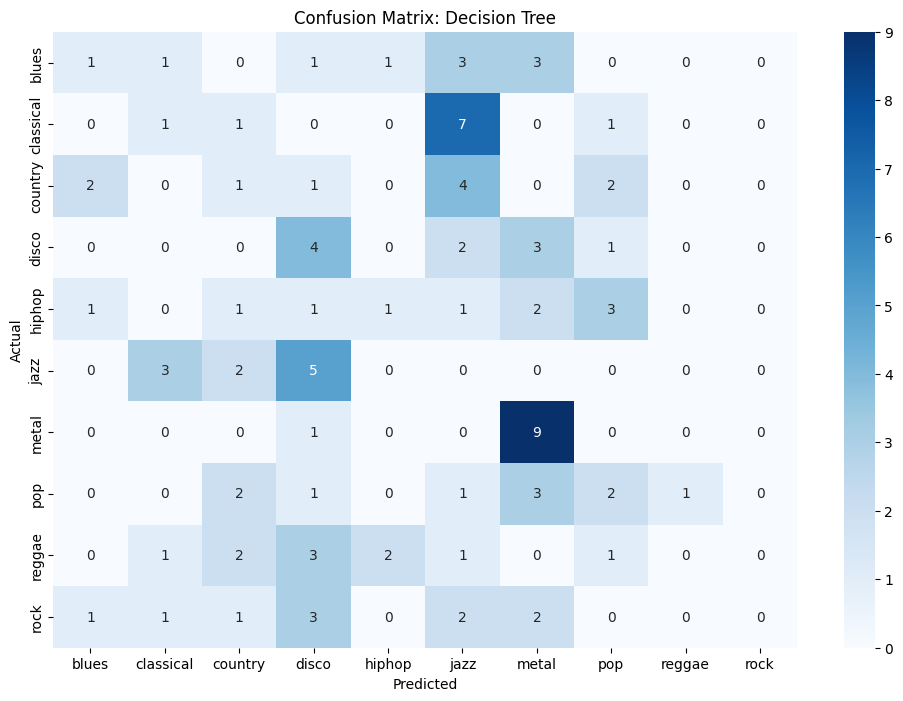

       Genre  TP  TN  FP  FN
0      blues   1  86   4   9
1  classical   1  84   6   9
2    country   1  81   9   9
3      disco   4  74  16   6
4     hiphop   1  87   3   9
5       jazz   0  69  21  10
6      metal   9  77  13   1
7        pop   2  82   8   8
8     reggae   0  89   1  10
9       rock   0  90   0  10


In [9]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

'''
YOUR CODE HERE

y_pred = # COMPUTE PREDICTED VALUES
macro_f1 = # COMPUTE VALIDATION MACRO F1 SCORE
cm = # COMPUTE CONFUSION MATRIX
cr = # COMPUTE CLASSIFICATION REPORT

'''
y_pred = clf.predict(X_val)
macro_f1 = f1_score(y_val, y_pred, average='macro')
cm = confusion_matrix(y_val, y_pred)
cr = classification_report(y_val, y_pred)

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

'''
YOUR CODE HERE

Visualize the confusion matrix and compute TP, TN, FP, FN for all genres.
'''
#  Visualization and Per-Genre Metrics 
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=GENRES, yticklabels=GENRES, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Decision Tree')
plt.show()

# Compute TP, TN, FP, FN for each genre
metrics_summary = []
for i, genre in enumerate(GENRES):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - (tp + fp + fn)
    metrics_summary.append({
        'Genre': genre,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    })

metrics_df = pd.DataFrame(metrics_summary)
print(metrics_df)

In [10]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')

GENRES = ["blues", "classical", "country", "disco",
          "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

In [11]:
def extract_features_safe(song_path):
    
    # auto detect stem name
    possible_files = ['other.wav', 'others.wav']
    file_path = None
    
    for fname in possible_files:
        temp_path = os.path.join(song_path, fname)
        if os.path.exists(temp_path):
            file_path = temp_path
            break
    
    if file_path is None:
        return None
    
    try:
        y, sr = librosa.load(file_path, sr=22050, duration=10)
        
        if len(y) == 0:
            return None
        
        tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
        spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))
        rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
        
        return [float(tempo), spec_cent, zcr, rolloff]
    
    except:
        return None

In [12]:
data = []

for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    
    for s in songs[:50]:   # speed ke liye
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['genre'],
    random_state=42
)

In [13]:
X_train = []
y_train = []

for path, genre in zip(train_df['path'], train_df['genre']):
    features = extract_features_safe(path)
    if features is not None:
        X_train.append(features)
        y_train.append(genre)

X_val = []
y_val = []

for path, genre in zip(val_df['path'], val_df['genre']):
    features = extract_features_safe(path)
    if features is not None:
        X_val.append(features)
        y_val.append(genre)

X_train = np.array(X_train)
X_val = np.array(X_val)

print("Train samples:", len(X_train))
print("Validation samples:", len(X_val))

/tmp/ipykernel_17/3414979543.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]


Train samples: 400
Validation samples: 100


In [14]:
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [15]:
y_val_arr = np.array(y_val)
y_pred = clf.predict(X_val)
macro_f1 = f1_score(y_val_arr, y_pred, average='macro')
cm = confusion_matrix(y_val_arr, y_pred, labels=GENRES)
cr = classification_report(y_val_arr, y_pred, output_dict=True)  # output_dict=True!

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")

Validation Macro F1 Score: 0.1523



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
print("Answer Q10 (Recall pop):", cr['pop']['recall'])

Answer Q10 (Recall pop): 0.2


In [17]:
accuracy = np.mean(np.array(y_pred) == np.array(y_val))
print("Answer Q11 (Accuracy):", accuracy)

Answer Q11 (Accuracy): 0.19


In [18]:
cm = confusion_matrix(y_val, y_pred, labels=GENRES)

tp_dict = {}

for i, genre in enumerate(GENRES):
    TP = cm[i, i]
    tp_dict[genre] = TP

print("Answer Q12 (Highest TP Genre):", max(tp_dict, key=tp_dict.get))

Answer Q12 (Highest TP Genre): metal


In [19]:
fn_dict = {}

for i, genre in enumerate(GENRES):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    fn_dict[genre] = FN

print("Answer Q13 (Lowest FN Genre):", min(fn_dict, key=fn_dict.get))

Answer Q13 (Lowest FN Genre): metal
